In [1]:
from tqec import BlockGraph
from tqec.utils.position import Position3D

In [2]:


g = BlockGraph("CNOT")
cubes = [
    (Position3D(0, 0, 0), "P", "In_Control"),
    (Position3D(0, 0, 1), "ZXX", ""),
    (Position3D(0, 0, 2), "ZXZ", ""),
    (Position3D(0, 0, 3), "P", "Out_Control"),
    (Position3D(0, 1, 1), "ZXX", ""),
    (Position3D(0, 1, 2), "ZXZ", ""),
    (Position3D(1, 1, 0), "P", "In_Target"),
    (Position3D(1, 1, 1), "ZXZ", ""),
    (Position3D(1, 1, 2), "ZXZ", ""),
    (Position3D(1, 1, 3), "P", "Out_Target"),
]
for pos, kind, label in cubes:
    g.add_cube(pos, kind, label)

pipes = [(0, 1), (1, 2), (2, 3), (1, 4), (4, 5), (5, 8), (6, 7), (7, 8), (8, 9)]

for p0, p1 in pipes:
    g.add_pipe(cubes[p0][0], cubes[p1][0])

g.view_as_html()

In [4]:
from tqec.computation.correlation import find_correlation_surfaces

zx = g.to_zx_graph()        # BlockGraph → PyZX GraphS
surfaces = find_correlation_surfaces(zx.g)   # list[CorrelationSurface]

# Get the logical operator supported on the ports for each surface
for surface in surfaces:
    print(surface)
    print(surface.external_stabilizer_on_graph(g))

CorrelationSurface(span=frozenset({ZXEdge(u=ZXNode(id=1, basis=Basis.X), v=ZXNode(id=4, basis=Basis.X)), ZXEdge(u=ZXNode(id=7, basis=Basis.X), v=ZXNode(id=8, basis=Basis.X)), ZXEdge(u=ZXNode(id=6, basis=Basis.X), v=ZXNode(id=7, basis=Basis.X)), ZXEdge(u=ZXNode(id=0, basis=Basis.X), v=ZXNode(id=1, basis=Basis.X)), ZXEdge(u=ZXNode(id=1, basis=Basis.X), v=ZXNode(id=2, basis=Basis.X)), ZXEdge(u=ZXNode(id=5, basis=Basis.X), v=ZXNode(id=8, basis=Basis.X)), ZXEdge(u=ZXNode(id=2, basis=Basis.X), v=ZXNode(id=3, basis=Basis.X)), ZXEdge(u=ZXNode(id=4, basis=Basis.X), v=ZXNode(id=5, basis=Basis.X))}))
XXXI
CorrelationSurface(span=frozenset({ZXEdge(u=ZXNode(id=1, basis=Basis.X), v=ZXNode(id=4, basis=Basis.X)), ZXEdge(u=ZXNode(id=8, basis=Basis.X), v=ZXNode(id=9, basis=Basis.X)), ZXEdge(u=ZXNode(id=0, basis=Basis.X), v=ZXNode(id=1, basis=Basis.X)), ZXEdge(u=ZXNode(id=1, basis=Basis.X), v=ZXNode(id=2, basis=Basis.X)), ZXEdge(u=ZXNode(id=5, basis=Basis.X), v=ZXNode(id=8, basis=Basis.X)), ZXEdge(u=ZXNo

In [5]:
#"ZXZ", "XZZ", "ZXX", "XZX", "XXZ", "ZZX" #all kinds

g = BlockGraph("CNOT")
cubes = [
    (Position3D(0, 0, 0), "P", "In_Control"), #port only visible as soon as pipe connected to it
    (Position3D(0, 0, 1), "ZXZ", ""),
    (Position3D(0, 1, 1), "XZZ", ""),
    (Position3D(0, 2, 1), "ZXX", ""),
    (Position3D(0, 3, 1), "XZX", ""),
    (Position3D(0, 4, 1), "XXZ", ""),
    (Position3D(0, 5, 1), "ZZX", ""),

]
for pos, kind, label in cubes:
    g.add_cube(pos, kind, label)

pipes =  [(0,1)]#[(0, 1), (1, 2), (2, 3), (1, 4), (4, 5), (5, 8), (6, 7), (7, 8), (8, 9)]

for p0, p1 in pipes:
    g.add_pipe(cubes[p0][0], cubes[p1][0])

g.view_as_html()

In [6]:
for position, attrs in g._graph.nodes(data=True):
    cube = attrs[g._NODE_DATA_KEY]
    print(position, cube.kind, cube.label)

(0,0,0) PORT In_Control
(0,0,1) ZXZ 
(0,1,1) XZZ 
(0,2,1) ZXX 
(0,3,1) XZX 
(0,4,1) XXZ 
(0,5,1) ZZX 


In [7]:
g._graph.nodes(data=True)

NodeDataView({Position3D(x=0, y=0, z=0): {'tqec_node_data': Cube(position=Position3D(x=0, y=0, z=0), kind=<tqec.computation.cube.Port object at 0x71b5c1ab4850>, label='In_Control')}, Position3D(x=0, y=0, z=1): {'tqec_node_data': Cube(position=Position3D(x=0, y=0, z=1), kind=ZXCube(x=Basis.Z, y=Basis.X, z=Basis.Z), label='')}, Position3D(x=0, y=1, z=1): {'tqec_node_data': Cube(position=Position3D(x=0, y=1, z=1), kind=ZXCube(x=Basis.X, y=Basis.Z, z=Basis.Z), label='')}, Position3D(x=0, y=2, z=1): {'tqec_node_data': Cube(position=Position3D(x=0, y=2, z=1), kind=ZXCube(x=Basis.Z, y=Basis.X, z=Basis.X), label='')}, Position3D(x=0, y=3, z=1): {'tqec_node_data': Cube(position=Position3D(x=0, y=3, z=1), kind=ZXCube(x=Basis.X, y=Basis.Z, z=Basis.X), label='')}, Position3D(x=0, y=4, z=1): {'tqec_node_data': Cube(position=Position3D(x=0, y=4, z=1), kind=ZXCube(x=Basis.X, y=Basis.X, z=Basis.Z), label='')}, Position3D(x=0, y=5, z=1): {'tqec_node_data': Cube(position=Position3D(x=0, y=5, z=1), kind=

In [8]:
for position, attrs in g._graph.nodes(data=True):
    cube = attrs['tqec_node_data']
    kind = cube.kind
    print(position, type(kind), kind)

(0,0,0) <class 'tqec.computation.cube.Port'> PORT
(0,0,1) <class 'tqec.computation.cube.ZXCube'> ZXZ
(0,1,1) <class 'tqec.computation.cube.ZXCube'> XZZ
(0,2,1) <class 'tqec.computation.cube.ZXCube'> ZXX
(0,3,1) <class 'tqec.computation.cube.ZXCube'> XZX
(0,4,1) <class 'tqec.computation.cube.ZXCube'> XXZ
(0,5,1) <class 'tqec.computation.cube.ZXCube'> ZZX


In [9]:
import tqec
tqec.computation.cube.Cube(Position3D(0,0,0), "ZXX", "")

Cube(position=Position3D(x=0, y=0, z=0), kind='ZXX', label='')

In [10]:
tqec.computation.cube.ZXCube(x="Z", y="Z", z="X")

ZXCube(x='Z', y='Z', z='X')

In [11]:
print(g._graph.edges(data=True))

[(Position3D(x=0, y=0, z=0), Position3D(x=0, y=0, z=1), {'tqec_edge_data': Pipe(u=Cube(position=Position3D(x=0, y=0, z=0), kind=<tqec.computation.cube.Port object at 0x71b5c1ab4850>, label='In_Control'), v=Cube(position=Position3D(x=0, y=0, z=1), kind=ZXCube(x=Basis.Z, y=Basis.X, z=Basis.Z), label=''), kind=PipeKind(x=Basis.Z, y=Basis.X, z=None, has_hadamard=False))})]


# PRISMS

In [1]:
import sys
sys.path.append("/mnt/c/Users/Laura/Documents/Codes_and_Repos/tqec_cococo/tqec/src/tqec/computation")

import importlib

import prism 
import prism_graph
import pipe_prism

importlib.reload(prism)
importlib.reload(prism_graph)
importlib.reload(pipe_prism)

<module 'pipe_prism' from '/mnt/c/Users/Laura/Documents/Codes_and_Repos/tqec_cococo/tqec/src/tqec/computation/pipe_prism.py'>

In [2]:
prism.ZXPrism(prep = "N", meas = "X")

ZXPrism(prep='N', meas='X')

In [3]:
prism.ZXPrism.from_str("NX")

ZXPrism(prep=<BasisPrism.N: 'N'>, meas=<BasisPrism.X: 'X'>)

In [4]:
otherpos = prism.Position3DHex(x = 2, y = 0, z = 0)
pos = prism.Position3DHex(x = 1, y = 1, z = 0)

pos.is_neighbour(otherpos)

True

check restrictions for temporal pipes and their connecting prisms

In [5]:
g = prism_graph.PrismGraph("test")

prisms = [
    (prism.Position3DHex(0,0,0), "XN", "test2"),
    (prism.Position3DHex(0,0,1), "NX", "test3")
]

for pos, kind, label in prisms:
    g.add_prism(pos, kind, label)


In [6]:
g._graph.nodes(data=True)

NodeDataView({Position3DHex(x=0, y=0, z=0): {'tqec_node_data': Prism(position=Position3DHex(x=0, y=0, z=0), kind=ZXPrism(prep=<BasisPrism.X: 'X'>, meas=<BasisPrism.N: 'N'>), label='test2')}, Position3DHex(x=0, y=0, z=1): {'tqec_node_data': Prism(position=Position3DHex(x=0, y=0, z=1), kind=ZXPrism(prep=<BasisPrism.N: 'N'>, meas=<BasisPrism.X: 'X'>), label='test3')}})

In [7]:
for position, attrs in g._graph.nodes(data=True):
    cube = attrs['tqec_node_data']
    kind = cube.kind
    print(position, type(kind), kind)

Position3DHex(x=0, y=0, z=0) <class 'prism.ZXPrism'> XN
Position3DHex(x=0, y=0, z=1) <class 'prism.ZXPrism'> NX


In [8]:
pipe_kind = pipe_prism.PrismPipeKind(hor = prism.BasisPrism.N, ver = prism.BasisPrism.N)
g.add_pipe(prisms[0][0], prisms[1][0], pipe_kind)

In [9]:
g._graph.edges(data=True)

EdgeDataView([(Position3DHex(x=0, y=0, z=0), Position3DHex(x=0, y=0, z=1), {'tqec_edge_data': PrismPipe(u=Prism(position=Position3DHex(x=0, y=0, z=0), kind=ZXPrism(prep=<BasisPrism.X: 'X'>, meas=<BasisPrism.N: 'N'>), label='test2'), v=Prism(position=Position3DHex(x=0, y=0, z=1), kind=ZXPrism(prep=<BasisPrism.N: 'N'>, meas=<BasisPrism.X: 'X'>), label='test3'), kind=PrismPipeKind(hor=<BasisPrism.N: 'N'>, ver=<BasisPrism.N: 'N'>, has_hadamard=False))})])

check restrictions for spatial pipes and their connecting prisms

In [10]:
g = prism_graph.PrismGraph("test")

prisms = [
    (prism.Position3DHex(0,1,0), "XN", "test2"),
    (prism.Position3DHex(-1,0,0), "NX", "test3")
]

for pos, kind, label in prisms:
    g.add_prism(pos, kind, label)


In [11]:
g._graph.nodes(data=True)

NodeDataView({Position3DHex(x=0, y=1, z=0): {'tqec_node_data': Prism(position=Position3DHex(x=0, y=1, z=0), kind=ZXPrism(prep=<BasisPrism.X: 'X'>, meas=<BasisPrism.N: 'N'>), label='test2')}, Position3DHex(x=-1, y=0, z=0): {'tqec_node_data': Prism(position=Position3DHex(x=-1, y=0, z=0), kind=ZXPrism(prep=<BasisPrism.N: 'N'>, meas=<BasisPrism.X: 'X'>), label='test3')}})

In [12]:
for position, attrs in g._graph.nodes(data=True):
    cube = attrs['tqec_node_data']
    kind = cube.kind
    print(position, type(kind), kind)

Position3DHex(x=0, y=1, z=0) <class 'prism.ZXPrism'> XN
Position3DHex(x=-1, y=0, z=0) <class 'prism.ZXPrism'> NX


In [13]:
pipe_kind = pipe_prism.PrismPipeKind(hor = prism.BasisPrism.X, ver = prism.BasisPrism.Z)
g.add_pipe(prisms[0][0], prisms[1][0], pipe_kind)

In [14]:
g._graph.edges(data=True)

EdgeDataView([(Position3DHex(x=0, y=1, z=0), Position3DHex(x=-1, y=0, z=0), {'tqec_edge_data': PrismPipe(u=Prism(position=Position3DHex(x=-1, y=0, z=0), kind=ZXPrism(prep=<BasisPrism.N: 'N'>, meas=<BasisPrism.X: 'X'>), label='test3'), v=Prism(position=Position3DHex(x=0, y=1, z=0), kind=ZXPrism(prep=<BasisPrism.X: 'X'>, meas=<BasisPrism.N: 'N'>), label='test2'), kind=PrismPipeKind(hor=<BasisPrism.X: 'X'>, ver=<BasisPrism.Z: 'Z'>, has_hadamard=False))})])

Red junction rank-2 spatial, rank-2 temporal

In [15]:
g = prism_graph.PrismGraph("red junction")

prisms = [
    (prism.Position3DHex(0,0,1), "NN", "middle"),
    (prism.Position3DHex(0,0,2), "NN", "top"),
    (prism.Position3DHex(0,0,0), "NN", "bottom"),
    (prism.Position3DHex(1,1,1), "NN", "left"),
    (prism.Position3DHex(-1,1,1), "NN", "right"),

]

for pos, kind, label in prisms:
    g.add_prism(pos, kind, label)

In [16]:
#middle bottom
pipe_kind = pipe_prism.PrismPipeKind(hor = prism.BasisPrism.N, ver = prism.BasisPrism.N)
g.add_pipe(prisms[0][0], prisms[2][0], pipe_kind)

#middle top
pipe_kind = pipe_prism.PrismPipeKind(hor = prism.BasisPrism.N, ver = prism.BasisPrism.N)
g.add_pipe(prisms[0][0], prisms[1][0], pipe_kind)

#middle left
pipe_kind = pipe_prism.PrismPipeKind(hor = prism.BasisPrism.X, ver = prism.BasisPrism.Z)
g.add_pipe(prisms[0][0], prisms[3][0], pipe_kind)

#middle right
pipe_kind = pipe_prism.PrismPipeKind(hor = prism.BasisPrism.X, ver = prism.BasisPrism.Z)
g.add_pipe(prisms[0][0], prisms[4][0], pipe_kind)

In [17]:
sys.path.append("/mnt/c/Users/Laura/Documents/Codes_and_Repos/tqec_cococo/tqec/src/tqec/interop/collada")

import io
from prism import Position3DHex
from prism_graph import PrismGraph
from read_write_prism import write_prism_graph_to_dae_file
from html_viewer import display_collada_model

# ...or entirely in memory without touching disk
buf = io.BytesIO()
write_prism_graph_to_dae_file(g, buf, spacing = 3.0)
display_collada_model(buf.getvalue())  # pass bytes directly

teleportation

In [18]:
g = prism_graph.PrismGraph("teleportation")

prisms = [
    (prism.Position3DHex(0,0,0), "XN", "start"),
    (prism.Position3DHex(0,0,1), "NX", "1"),
    (prism.Position3DHex(-1,1,1), "XN", "2"),
    (prism.Position3DHex(-1,1,2), "NX", "end"),

]

for pos, kind, label in prisms:
    g.add_prism(pos, kind, label)

In [19]:
#start-1
pipe_kind = pipe_prism.PrismPipeKind(hor = prism.BasisPrism.N, ver = prism.BasisPrism.N)
g.add_pipe(prisms[0][0], prisms[1][0], pipe_kind)

#1-2
pipe_kind = pipe_prism.PrismPipeKind(hor = prism.BasisPrism.X, ver = prism.BasisPrism.Z)
g.add_pipe(prisms[1][0], prisms[2][0], pipe_kind)

#2-end
pipe_kind = pipe_prism.PrismPipeKind(hor = prism.BasisPrism.N, ver = prism.BasisPrism.N)
g.add_pipe(prisms[2][0], prisms[3][0], pipe_kind)

In [20]:
sys.path.append("/mnt/c/Users/Laura/Documents/Codes_and_Repos/tqec_cococo/tqec/src/tqec/interop/collada")

import io
from prism import Position3DHex
from prism_graph import PrismGraph
from read_write_prism import write_prism_graph_to_dae_file
from html_viewer import display_collada_model

# ...or entirely in memory without touching disk
buf = io.BytesIO()
write_prism_graph_to_dae_file(g, buf, spacing = 3.0)
display_collada_model(buf.getvalue())  # pass bytes directly

# visualization

In [21]:
sys.path.append("/mnt/c/Users/Laura/Documents/Codes_and_Repos/tqec_cococo/tqec/src/tqec/interop/collada")

import io
from prism import Position3DHex
from prism_graph import PrismGraph
from read_write_prism import write_prism_graph_to_dae_file
from html_viewer import display_collada_model

# 1. build your graph
g = PrismGraph("test")


prisms = [(Position3DHex(2, 2, 0), "XN", ""),
            (Position3DHex(1, 3, 0), "XX", ""),
            (Position3DHex(3, 3, 0), "XX", ""),
            (Position3DHex(3, 1, 0), "XX", ""),
            (Position3DHex(0, 4, 0), "XX", ""),
            (Position3DHex(-1,5, 0), "ZZ", ""),

            (Position3DHex(2, 2, 1), "NX", ""),
]
for pos, kind, label in prisms:
    g.add_prism(pos, kind, label)

#add some edges
pipe_kind = pipe_prism.PrismPipeKind(hor = prism.BasisPrism.X, ver = prism.BasisPrism.Z)
g.add_pipe(prisms[0][0], prisms[1][0], pipe_kind)

pipe_kind = pipe_prism.PrismPipeKind(hor = prism.BasisPrism.N, ver = prism.BasisPrism.N)
g.add_pipe(prisms[0][0], prisms[6][0], pipe_kind)

#pipe_kind = pipe_prism.PrismPipeKind(hor = prism.BasisPrism.X, ver = prism.BasisPrism.Z)
#g.add_pipe(prisms[0][0], prisms[2][0], pipe_kind)

#pipe_kind = pipe_prism.PrismPipeKind(hor = prism.BasisPrism.X, ver = prism.BasisPrism.Z)
#g.add_pipe(prisms[0][0], prisms[3][0], pipe_kind)

# 2. write to DAE — either to a file...
#write_prism_graph_to_dae_file(g, "my_prisms.dae", spacing = 1.0)
#display_collada_model("my_prisms.dae")

# ...or entirely in memory without touching disk
buf = io.BytesIO()
write_prism_graph_to_dae_file(g, buf, spacing = 3.0)
display_collada_model(buf.getvalue())  # pass bytes directly

understand how correlation surfaces are built for the surface code + how distance dependent things come into play (stabilizers and the stim circuit finally)

In [6]:
from tqec import BlockGraph, compile_block_graph, NoiseModel
from tqec.utils.position import Position3D

In [7]:


g = BlockGraph("CNOT")
cubes = [
    (Position3D(0, 0, 0), "P", "In_Control"),
    (Position3D(0, 0, 1), "ZXX", ""),
    (Position3D(0, 0, 2), "ZXZ", ""),
    (Position3D(0, 0, 3), "P", "Out_Control"),
    (Position3D(0, 1, 1), "ZXX", ""),
    (Position3D(0, 1, 2), "ZXZ", ""),
    (Position3D(1, 1, 0), "P", "In_Target"),
    (Position3D(1, 1, 1), "ZXZ", ""),
    (Position3D(1, 1, 2), "ZXZ", ""),
    (Position3D(1, 1, 3), "P", "Out_Target"),
]
for pos, kind, label in cubes:
    g.add_cube(pos, kind, label)

pipes = [(0, 1), (1, 2), (2, 3), (1, 4), (4, 5), (5, 8), (6, 7), (7, 8), (8, 9)]

for p0, p1 in pipes:
    g.add_pipe(cubes[p0][0], cubes[p1][0])

#! ports need to be filled for sim
filled_graphs = g.fill_ports_for_minimal_simulation()

filled_graphs[0].graph.view_as_html()

nodes pos [[0 0 0 0 0 0 1 1 1 1]
 [0 0 0 0 1 1 1 1 1 1]
 [0 1 2 3 1 2 0 1 2 3]]


(<Figure size 500x600 with 1 Axes>, <Axes3D: >)

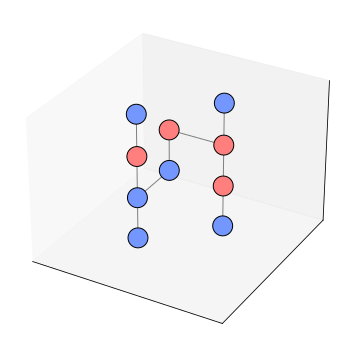

In [8]:
g = filled_graphs[0].graph

zx = g.to_zx_graph()
zx.draw()

In [4]:

correlation_surfaces = g.find_correlation_surfaces()
print(correlation_surfaces)

#returns TopologicalComputationGraph
compiled_computation = compile_block_graph(g, observables=[correlation_surfaces[1]])

[CorrelationSurface(span=frozenset({ZXEdge(u=ZXNode(id=5, basis=Basis.X), v=ZXNode(id=8, basis=Basis.X)), ZXEdge(u=ZXNode(id=7, basis=Basis.X), v=ZXNode(id=8, basis=Basis.X)), ZXEdge(u=ZXNode(id=6, basis=Basis.X), v=ZXNode(id=7, basis=Basis.X)), ZXEdge(u=ZXNode(id=1, basis=Basis.X), v=ZXNode(id=2, basis=Basis.X)), ZXEdge(u=ZXNode(id=4, basis=Basis.X), v=ZXNode(id=5, basis=Basis.X)), ZXEdge(u=ZXNode(id=0, basis=Basis.X), v=ZXNode(id=1, basis=Basis.X)), ZXEdge(u=ZXNode(id=2, basis=Basis.X), v=ZXNode(id=3, basis=Basis.X)), ZXEdge(u=ZXNode(id=1, basis=Basis.X), v=ZXNode(id=4, basis=Basis.X))})), CorrelationSurface(span=frozenset({ZXEdge(u=ZXNode(id=8, basis=Basis.X), v=ZXNode(id=9, basis=Basis.X)), ZXEdge(u=ZXNode(id=5, basis=Basis.X), v=ZXNode(id=8, basis=Basis.X)), ZXEdge(u=ZXNode(id=1, basis=Basis.X), v=ZXNode(id=2, basis=Basis.X)), ZXEdge(u=ZXNode(id=4, basis=Basis.X), v=ZXNode(id=5, basis=Basis.X)), ZXEdge(u=ZXNode(id=0, basis=Basis.X), v=ZXNode(id=1, basis=Basis.X)), ZXEdge(u=ZXNode(

In [5]:
#TopologicalComputationGraph.generate_stim_circuit contains theise calls

layer = compiled_computation.to_layer_tree()

print(layer.to_dict())


{'root': {'layer': 'SequencedLayers', 'children': [{'layer': 'SequencedLayers', 'children': [{'layer': 'LayoutLayer', 'children': [], 'annotations': {}}, {'layer': 'RepeatedLayer', 'children': [{'layer': 'LayoutLayer', 'children': [], 'annotations': {}}], 'annotations': {}}, {'layer': 'LayoutLayer', 'children': [], 'annotations': {}}], 'annotations': {}}, {'layer': 'SequencedLayers', 'children': [{'layer': 'LayoutLayer', 'children': [], 'annotations': {}}, {'layer': 'RepeatedLayer', 'children': [{'layer': 'LayoutLayer', 'children': [], 'annotations': {}}], 'annotations': {}}, {'layer': 'LayoutLayer', 'children': [], 'annotations': {}}], 'annotations': {}}, {'layer': 'SequencedLayers', 'children': [{'layer': 'LayoutLayer', 'children': [], 'annotations': {}}, {'layer': 'RepeatedLayer', 'children': [{'layer': 'LayoutLayer', 'children': [], 'annotations': {}}], 'annotations': {}}, {'layer': 'LayoutLayer', 'children': [], 'annotations': {}}], 'annotations': {}}, {'layer': 'SequencedLayers',

In [6]:
circuit = layer.generate_circuit()

TypeError: LayerTree.generate_circuit() missing 1 required positional argument: 'k'

example for coco into zx diagram 

# important! import properly, change imports above, otherwise it wont work anymore

## teleportation zx diagram

In [1]:
from tqec.computation import prism_graph, prism, pipe_prism
# or
from tqec.computation.prism import BasisPrism
from tqec.computation.pipe_prism import PrismPipeKind
from tqec.computation.prism_graph import PrismGraph

In [2]:
g = prism_graph.PrismGraph("teleportation")

prisms = [
    (prism.Position3DHex(0,0,0), "ZN", "start"),
    (prism.Position3DHex(0,0,1), "NZ", "1"),
    (prism.Position3DHex(-1,1,1), "ZN", "2"),
    (prism.Position3DHex(-1,1,2), "NZ", "end"),

]

for pos, kind, label in prisms:
    g.add_prism(pos, kind, label)

In [3]:
#start-1
pipe_kind = pipe_prism.PrismPipeKind(hor = prism.BasisPrism.N, ver = prism.BasisPrism.N)
g.add_pipe(prisms[0][0], prisms[1][0], pipe_kind)

#1-2
pipe_kind = pipe_prism.PrismPipeKind(hor = prism.BasisPrism.Z, ver = prism.BasisPrism.X)
g.add_pipe(prisms[1][0], prisms[2][0], pipe_kind)

#2-end
pipe_kind = pipe_prism.PrismPipeKind(hor = prism.BasisPrism.N, ver = prism.BasisPrism.N)
g.add_pipe(prisms[2][0], prisms[3][0], pipe_kind)

In [4]:
g.view_as_html()

total neighbors 1
type kind ZN
--
False
True
len neighbor pipes spatial 0
len temporal neighbor pipes 1
total neighbors 2
type kind NZ
--
False
True
--
True
False
len neighbor pipes spatial 1
len temporal neighbor pipes 1
list_ver [<BasisPrism.X: 'X'>]
list_hor [<BasisPrism.Z: 'Z'>]
total neighbors 2
type kind ZN
--
True
False
--
False
True
len neighbor pipes spatial 1
len temporal neighbor pipes 1
list_ver [<BasisPrism.X: 'X'>]
list_hor [<BasisPrism.Z: 'Z'>]
total neighbors 1
type kind NZ
--
False
True
len neighbor pipes spatial 0
len temporal neighbor pipes 1
vertex 0: pos=Position3DHex(x=0, y=0, z=0), euclidean=(0.0, 0.0, 0.0)
vertex 1: pos=Position3DHex(x=0, y=0, z=1), euclidean=(0.0, 0.0, 1.0)
vertex 2: pos=Position3DHex(x=-1, y=1, z=1), euclidean=(-0.5, 0.0, 1.0)
vertex 3: pos=Position3DHex(x=-1, y=1, z=2), euclidean=(-0.5, 0.0, 2.0)
vis_nodes_array shape: (3, 4)
vis_nodes_array:
 [[ 0.   0.  -0.5 -0.5]
 [ 0.   0.   0.   0. ]
 [ 0.   1.   1.   2. ]]


(<Figure size 500x600 with 1 Axes>, <Axes3D: >)

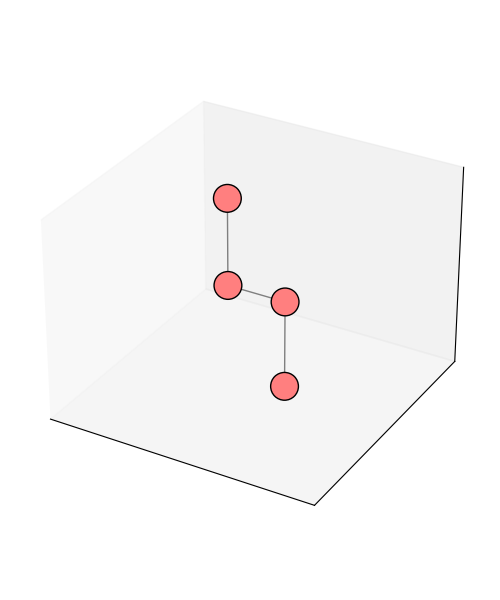

In [5]:
%matplotlib ipympl
zx = g.to_zx_graph()
zx.draw()


## 

## cnot gate with induced zx diagram

In [6]:
from tqec.computation import prism_graph, prism, pipe_prism
# or
from tqec.computation.prism import BasisPrism
from tqec.computation.pipe_prism import PrismPipeKind
from tqec.computation.prism_graph import PrismGraph

In [7]:
g = prism_graph.PrismGraph("CNOT")

prisms = [
    (prism.Position3DHex(3,3,0), "PORT", "target-int"),
    (prism.Position3DHex(3,3,1), "NN", ""),
    (prism.Position3DHex(3,3,2), "NN", ""),
    (prism.Position3DHex(3,3,3), "PORT", "target-out"),

    (prism.Position3DHex(2,2,1), "XN", ""),
    (prism.Position3DHex(2,2,2), "NZ", ""),

    (prism.Position3DHex(1,3,0), "PORT", "control-in"),
    (prism.Position3DHex(1,3,1), "NN", ""),
    (prism.Position3DHex(1,3,2), "NN", ""),
    (prism.Position3DHex(1,3,3), "PORT", "control-out"),


]

for pos, kind, label in prisms:
    g.add_prism(pos, kind, label)

In [8]:
#c temp
pipe_kind = pipe_prism.PrismPipeKind(hor = prism.BasisPrism.N, ver = prism.BasisPrism.N)
g.add_pipe(prisms[0][0], prisms[1][0], pipe_kind)

pipe_kind = pipe_prism.PrismPipeKind(hor = prism.BasisPrism.N, ver = prism.BasisPrism.N)
g.add_pipe(prisms[1][0], prisms[2][0], pipe_kind)

pipe_kind = pipe_prism.PrismPipeKind(hor = prism.BasisPrism.N, ver = prism.BasisPrism.N)
g.add_pipe(prisms[2][0], prisms[3][0], pipe_kind)

#t temp
pipe_kind = pipe_prism.PrismPipeKind(hor = prism.BasisPrism.N, ver = prism.BasisPrism.N)
g.add_pipe(prisms[6][0], prisms[7][0], pipe_kind)

pipe_kind = pipe_prism.PrismPipeKind(hor = prism.BasisPrism.N, ver = prism.BasisPrism.N)
g.add_pipe(prisms[7][0], prisms[8][0], pipe_kind)

pipe_kind = pipe_prism.PrismPipeKind(hor = prism.BasisPrism.N, ver = prism.BasisPrism.N)
g.add_pipe(prisms[8][0], prisms[9][0], pipe_kind)

#spatial pipes
pipe_kind = pipe_prism.PrismPipeKind(hor = prism.BasisPrism.X, ver = prism.BasisPrism.Z)
g.add_pipe(prisms[1][0], prisms[4][0], pipe_kind)

pipe_kind = pipe_prism.PrismPipeKind(hor = prism.BasisPrism.Z, ver = prism.BasisPrism.X)
g.add_pipe(prisms[8][0], prisms[5][0], pipe_kind)

#middle temp
pipe_kind = pipe_prism.PrismPipeKind(hor = prism.BasisPrism.N, ver = prism.BasisPrism.N)
g.add_pipe(prisms[4][0], prisms[5][0], pipe_kind)

In [9]:
g.view_as_html()

total neighbors 1
type kind PORT
total neighbors 3
type kind NN
--
False
True
--
False
True
--
True
False
len neighbor pipes spatial 1
len temporal neighbor pipes 2
list_ver [<BasisPrism.Z: 'Z'>]
list_hor [<BasisPrism.X: 'X'>]
total neighbors 2
type kind NN
--
False
True
--
False
True
len neighbor pipes spatial 0
len temporal neighbor pipes 2
total neighbors 1
type kind PORT
total neighbors 2
type kind XN
--
True
False
--
False
True
len neighbor pipes spatial 1
len temporal neighbor pipes 1
list_ver [<BasisPrism.Z: 'Z'>]
list_hor [<BasisPrism.X: 'X'>]
total neighbors 2
type kind NZ
--
True
False
--
False
True
len neighbor pipes spatial 1
len temporal neighbor pipes 1
list_ver [<BasisPrism.X: 'X'>]
list_hor [<BasisPrism.Z: 'Z'>]
total neighbors 1
type kind PORT
total neighbors 2
type kind NN
--
False
True
--
False
True
len neighbor pipes spatial 0
len temporal neighbor pipes 2
total neighbors 3
type kind NN
--
False
True
--
False
True
--
True
False
len neighbor pipes spatial 1
len tempo

(<Figure size 500x600 with 1 Axes>, <Axes3D: >)

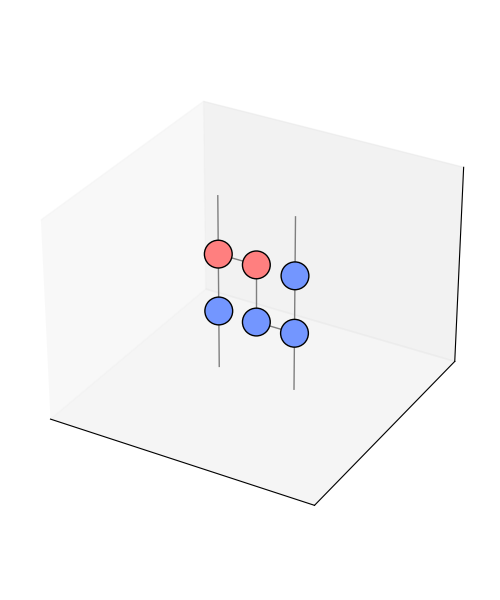

In [10]:
%matplotlib ipympl
zx = g.to_zx_graph()
zx.draw()

### todo: find rule for properly assigning zx color if prism only has temporal pipes

## spatial identity long

In [11]:
from tqec.computation import prism_graph, prism, pipe_prism
# or
from tqec.computation.prism import BasisPrism
from tqec.computation.pipe_prism import PrismPipeKind
from tqec.computation.prism_graph import PrismGraph

In [12]:
g = prism_graph.PrismGraph("Id")

prisms = [
    (prism.Position3DHex(0, 0, 0), "PORT", "in"),
    (prism.Position3DHex(1, 1, 0), "ZZ", ""),
    (prism.Position3DHex(2, 0, 0), "ZZ", ""),
    (prism.Position3DHex(3, 1, 0), "ZZ", ""),
    (prism.Position3DHex(2, 2, 0), "ZZ", ""),
    (prism.Position3DHex(1, 3, 0), "PORT", "out"),
]

for pos, kind, label in prisms:
    g.add_prism(pos, kind, label)

In [13]:
pipe_kind = pipe_prism.PrismPipeKind(hor = prism.BasisPrism.Z, ver = prism.BasisPrism.X)
g.add_pipe(prisms[0][0], prisms[1][0], pipe_kind)

pipe_kind = pipe_prism.PrismPipeKind(hor = prism.BasisPrism.Z, ver = prism.BasisPrism.X)
g.add_pipe(prisms[1][0], prisms[2][0], pipe_kind)

pipe_kind = pipe_prism.PrismPipeKind(hor = prism.BasisPrism.Z, ver = prism.BasisPrism.X)
g.add_pipe(prisms[2][0], prisms[3][0], pipe_kind)

pipe_kind = pipe_prism.PrismPipeKind(hor = prism.BasisPrism.Z, ver = prism.BasisPrism.X)
g.add_pipe(prisms[3][0], prisms[4][0], pipe_kind)

pipe_kind = pipe_prism.PrismPipeKind(hor = prism.BasisPrism.Z, ver = prism.BasisPrism.X)
g.add_pipe(prisms[4][0], prisms[5][0], pipe_kind)

In [14]:
g.view_as_html()

total neighbors 1
type kind PORT
total neighbors 2
type kind ZZ
--
True
False
--
True
False
len neighbor pipes spatial 2
len temporal neighbor pipes 0
list_ver [<BasisPrism.X: 'X'>, <BasisPrism.X: 'X'>]
list_hor [<BasisPrism.Z: 'Z'>, <BasisPrism.Z: 'Z'>]
total neighbors 2
type kind ZZ
--
True
False
--
True
False
len neighbor pipes spatial 2
len temporal neighbor pipes 0
list_ver [<BasisPrism.X: 'X'>, <BasisPrism.X: 'X'>]
list_hor [<BasisPrism.Z: 'Z'>, <BasisPrism.Z: 'Z'>]
total neighbors 2
type kind ZZ
--
True
False
--
True
False
len neighbor pipes spatial 2
len temporal neighbor pipes 0
list_ver [<BasisPrism.X: 'X'>, <BasisPrism.X: 'X'>]
list_hor [<BasisPrism.Z: 'Z'>, <BasisPrism.Z: 'Z'>]
total neighbors 2
type kind ZZ
--
True
False
--
True
False
len neighbor pipes spatial 2
len temporal neighbor pipes 0
list_ver [<BasisPrism.X: 'X'>, <BasisPrism.X: 'X'>]
list_hor [<BasisPrism.Z: 'Z'>, <BasisPrism.Z: 'Z'>]
total neighbors 1
type kind PORT
vertex 1: pos=Position3DHex(x=1, y=1, z=0), eu

(<Figure size 500x600 with 1 Axes>, <Axes3D: >)

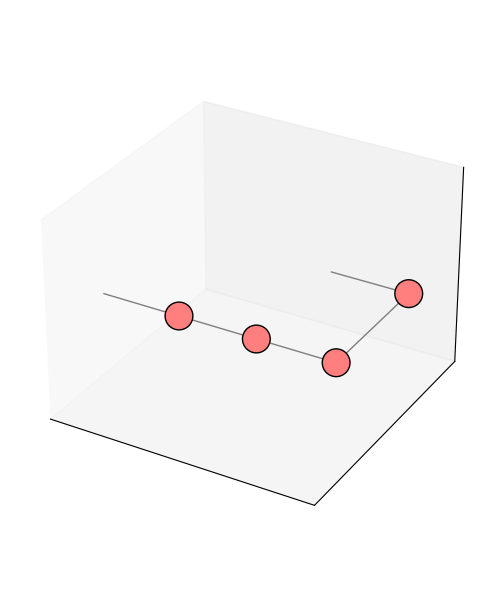

In [15]:
%matplotlib ipympl
zx = g.to_zx_graph()
zx.draw()